# Logistic Regression, SVM

## Binary Logistic Regression

The goal of this section is to analyze the performance of the Binary Logistic Regression Model on our dataset. <br>
The binary L.R. model is, despite its name, a classification model. If with GGM our goal was to model the distrIbution of samples given the classes, $X \mid C$, in this case we want to directly model the posterior distributions of the classes $C \mid X$. So, with the binary L.R. model we aim at modelling:
$$
P(C = 1 \mid \mathbf{x})
$$
$$
P(C = 0 \mid \mathbf{x}) = 1 - P(C = 1 \mid \mathbf{x})
$$
We can assume that the separation surface between classes is linear, so it's an hyperplane, so the decision function will be linear wrt to features $\mathbf{x}$:
$$
s(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b \gtrless t
$$
here $(\mathbf{w}, b)$ are the model parameters, which geometrically describe the hyperplane: $\mathbf{w}$ (*weights vector*) is the vector orthogonal to it and which determines its direction, and $b$ is the *bias* (or *intercept*), so it's a scalar which tells us how long we move along the direction of $\mathbf{w}$, from the origin (so, if $b = 0$, the hyerplane passes through the origin). <br>
The classification rule for a test sample $x_t$ is comparing the score $s(\mathbf{x}_t, \mathbf{w}, b)$ with a treshold $t$. If the application prior $\pi_T$ is equal to the empirical prior from the training set $\pi_{emp}^{LTR}$, and if we assume uniform costs for the two errors, the classification rule resolves in comparig the score with zero:
$$
s(\mathbf{x_t}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x}_t + b \gtrless 0
$$
So here $s(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b = 0$ is the decision surface which separates the two classes. If $s(\mathbf{x_t}, \mathbf{w}, b) > 0$, $x_t$ will get label 1, otherwise 0. <br>
The score can be written as the log posterior ratio:
$$
s(\mathbf{x}, \mathbf{w}, b) = \log \frac{P(C = 1 \mid \mathbf{x}, \mathbf{w}, b)}{P(C = 0 \mid \mathbf{x}, \mathbf{w}, b)}
$$
Remember that the log posterior ratio can in turn be written, using Bayes' Theorem, by the sum of the log likelihood ratio ($\text{llr}(\mathbf{x})$) and the prior log odds:
$$
s(\mathbf{x}, \mathbf{w}, b) = \log \frac{P(C = 1 \mid \mathbf{x}, \mathbf{w}, b)}{P(C = 0 \mid \mathbf{x}, \mathbf{w}, b)} = \log \frac{f_{X \mid C}(\mathbf{x} \mid C=1)}{f_{X \mid C}(\mathbf{x} \mid C=1)} + \log \frac{\pi}{1-\pi}
$$
So by exponentiating the first equation and solving it, having in mind that the two probabilities add up to $1$:
$$
\frac{P(C=1 \mid \mathbf{x}, \mathbf{w}, b)}{P(C=0 \mid \mathbf{x}, \mathbf{w}, b)} = e^{(\mathbf{w}^T \mathbf{x} + b)}
$$
We can find:
$$
P(C = 1 \mid \mathbf{x}, \mathbf{w}, b) = \frac{1}{1 + e^{- (\mathbf{w}^T + b)}} = \sigma(\mathbf{w}^T \mathbf{x} + b)
$$
$$
P(C = 0 \mid \mathbf{x}, \mathbf{w}, b) = 1 - P(C = 1 \mid \mathbf{x}, \mathbf{w}, b) = 1 - \sigma(\mathbf{w}^T \mathbf{x} + b) = \sigma(- (\mathbf{w}^T \mathbf{x} + b))
$$
The function $\sigma(t) = \frac{1}{1 + e^{-t}}$ is the **sigmoid**: it spans from 0 to 1 and has these properties:
- $\lim\limits_{t \rightarrow \infty} \sigma(t) = 1$
- $\lim\limits_{t \rightarrow - \infty} \sigma(t) = 0$
- $1- \sigma(t) = \sigma(- t)$

So, considering a test sample $\mathbf{x}_i$, we want to model the posteriors:
$$
P(C_i = 1 \mid \mathbf{x}_i, \mathbf{w}, b) = \sigma(\mathbf{w}^T \mathbf{x}_i + b)
$$
$$
P(C_i = 0 \mid \mathbf{x}_i, \mathbf{w}, b) = \sigma(- (\mathbf{w}^T \mathbf{x}_i + b))
$$
We can thus say that $C_i$ will assume value $1$ with probability $\sigma(\mathbf{w}^T \mathbf{x}_i + b)$, and value $0$ with probability $\sigma(- (\mathbf{w}^T \mathbf{x}_i + b))$ = $1 - \sigma(\mathbf{w}^T \mathbf{x}_i + b)$. So we can say that the distrubutions of labels wrt features and model parameters is a **Bernoulli distribution**:
$$
C_i \mid X_i, \mathbf{w}, b \sim \text{Bern}(\sigma(\mathbf{w}^T \mathbf{x}_i + b))
$$
The goal of training is to find a set of model parameters $(\mathbf{w}, b)$ which **best describes the observed labels on our dataset** (note that this is different from GGM where the goal was to find model parameters which best described the distribution of our data!). <br>
So, formalizing this, we start by assuming to have at our disposal a labeled dataset:
$$
\mathcal{D} = \left[ \left( x_1, c_1\right); ... ; \left( x_N, c_N\right) \right]
$$
We can assume classes are independently ditributed (however, they are **not** *i.i.d.* anymore, since in this case they depend on the specific sample $x_i$):
$$
C_i \mid \mathbf{x}_i, \mathbf{w}, b \sim C \mid \mathbf{x}_i, \mathbf{w}, b
$$
We can follow the frequentist approach and apply the **MLE**. So, we can compute the Likelihood:
$$
\mathcal{L} = P(C_1, ..., C_N \mid X_1, ... , X_N, \mathbf{w}, b) = \prod_{i=1}^{n} P(C_i = c \mid X_i = x_i, \mathbf{w}, b)
$$
Since the distributions are Bernoulli:
$$
\mathcal{L}(\mathbf{w}, b) = \prod_{i=1}^{n} \sigma(\mathbf{w}^T \mathbf{x}_i + b)^{c_i} \cdot (1 - \sigma(\mathbf{w}^T \mathbf{x}_i + b))^{(1 - c_i)}
$$
To simplify the notation we can call $y_i = \sigma(\mathbf{w}^T \mathbf{x}_i + b)$ (so, $y_i$ are the predicted labels):
$$
\mathcal{L}(\mathbf{w}, b) = \prod_{i=1}^{n} y_{i}^{c_i} \cdot (1 - y_i)^{(1 - c_i)}
$$
It's always more practical to work in the *log-domain*:
$$
\ell(\mathbf{w}, b) = \sum_{i = 1}^{n}\left[ c_i \log{y_i} + (1-c_i) \log(1- y_i) \right]
$$
So, the goal is to find the best model parameters $(\mathbf{w}^*, b^*)$ that maximize $\ell(\mathbf{w}, b)$. <br>
Now, $\ell(\mathbf{w}, b)$ is the first objective function interpretation. We can give another two interpretations. <br>

The first one is the **average cross-entropy** between the actual and predicted labels, which is the negative of $\ell(\mathbf{w}, b)$, apart from the $\frac{1}{n}$ term used to compute the average:
$$
\mathcal{J}(\mathbf{w}, b) = - \frac{1}{n} \sum_{i = 1}^{n}\left[ c_i \log{y_i} + (1-c_i) \log(1- y_i) \right]
$$
The cross-entropy between two distribution, $P$ and $Q$ is defined as such:
$$
H(P, Q) = -\mathbb{E}_{P(x)}\left[\log Q(x)\right]
$$
So, this is minimized when $P = Q$, so when the two distrubutions are equivalent. <br>
In our context, $\mathcal{J}(\mathbf{w}, b)$ tells us how far is the distribution of the labels predicted by our Recognizer $\mathcal{R}$, from the distributions of the actual labels, known by an observer ${\Large \varepsilon}$. So, long story short, minimizing this objective function means that **we want our predicted labels to be as similar as possible (ideally exactly equal) to the actual labels**. <br>

Another interpretation is the **average Logistic Loss function**, which is derived by the average cross-entropy by means of some semplifications (like writing the sigmoid complete formula) and this substitution: $z_i = 2 c_i - 1$:
$$
\mathcal{J}(\mathbf{w}, b) = \frac{1}{n} \sum_{i = 1}^{n} \log\left( 1 + e^{- z_i (\mathbf{w}^T \mathbf{x}_i + b)}\right)
$$
The function $\mathcal{l}(x) = \log\left( 1 + e^{- x}\right)$ is the Logistic Loss. <br>
This defines an **empirical risk**: it's empirical because it's related to potential missclassification errors, or even related to the cases where the classification is correct but not so certain (i.e. the point is very near the decision boundary). In fact, $\mathcal{l}(x)$ is asympthotically exponentially decreasing for $x > 0$ and asympthotically linearly increasing for $x \leq 0$. This means that for correctly classified samples we would have $z_i s_i > 0$, so the loss would exponentially decrase, depending on how far the correctly classified point is wrt the decision boundary, whereas for missclassified samples we would have $z_i s_i < 0$, so the loss would linearly get bigger and bigger, depending on how much we're wrong (i.e. how far from the decision boundary the missclassified point is). So in this case, minimizing the average Logistic Loss function means that we aim at a good, correct classification, so that the function is as low as possibile. Also, as already said, note that if a point gets correctlky classified but sits very near the classification rule, the loss won't be so small since there exist this uncertainity in classification, which is a risk. <br>

There are some limitations of this model. <br>
The first one is that, in the case where classes are **exactly separable** (which could seem the perfecty case for this model but in reality it's not!) the solution is **undefined**: in this case we cuould arbitrarily minimize the logistic loss function by incrementing the score, so incrementing the norm of $\mathbf{w}$ or the bias. In fact, remember that $\mathbf{w}^T \mathbf{x} + b$ is the decision surface if put $= 0$,  but also tell us how far from it a test point sits if it's either $> 0$ or $< 0$. So in this case the optimal solution would correspond to $\|\mathbf{w}\| \rightarrow \infty$. To overcome this problem we can artificially introduce a norm penalty term (also called regularization term) in the objective function, which is dependent on the hyperparameter $\lambda$:
$$
\frac{\lambda}{2} \|\mathbf{w}\|^2
$$
We can say that this forces to model to find simpler (so, more uncertain depending on the magnitude of $\lambda$) solution, but we avoid having $\|\mathbf{w}\| \rightarrow \infty$ in any cases. <br> Remember that if $\lambda$ gets too high, the class separation gets bad and the error rate increases, on the other hand if $\lambda$ gets too small, the model will make more confident solutions but will probably become over confident, leading to poor generalization when applied to validation sets, and overfitting. <br>

Another limitation of this model is that, since it directly computes posteriors, it is very infuenced by the empirical prior of the training dataset, $\pi_{emp}^{LTR}$. This can be an issue if we want to use applications having very different priors. In this case we can solve this by following two approaches. <br>
1) In the first approach we can manually subtract the empirical prior log odds of the training set from the score, making it resemble a log-likelihood ratio:
    $$
    s_{llr}(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b - \log \frac{\pi_{emp}^{LTR}}{1-\pi_{emp}^{LTR}}
    $$
    Then as classification rule we can compare this "llr like" score with the application prior log odds:
    $$
    s_{llr}(\mathbf{x}, \mathbf{w}, b) \gtrless \log \frac{\pi_{T}}{1-\pi_{T}}
    $$
2) In the second, genarally better, approach we operate directly at the objective function level, modelling a new objective function that is more sensitive to the application prior $\pi_T$ and which accounts for the relative contribution of each sample, by introducing a class-weight term. This approach is called **prior-weighted logistic regression**. Take for example the prior-weighted (also regularized for completeness) Logistic Loss function:
    $$
    \mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \sum_{i = 1}^{n} \xi_i \log \left( 1 + e^{-z_i (\mathbf{w}^T \mathbf{x}_i + b)}\right)
    $$
    Here we don't average the loss over all samples, as with the standard objective function, but we introduce the class weight $\xi_i$ which is proportional to target class priors and inversely proportional to the empirical frequency of that class in the training set:
    $$
    \xi_i = 
    \begin{cases}
    \frac{\pi_T}{n_T} \text{ if } z_i = 1 \\
    \frac{1-\pi_T}{n_F} \text{ if } z_i = -1
    \end{cases}
    $$
    where $n_T$ and $n_F = 1 - n_T$ are the number of samples belonging to each class.


### Non prior-weighted binary L.R.

So, having brifly explained the theory under this L.R. model, we can start considering the standard, non weighted version of it, without any pre-processing (like PCA). We just apply the regularization term and, because of the fact we want to use our primary application prior prior $\pi_T = 0.1$, which is different from the empirical prior of the training set, $\pi_{emp}^{LTR}$, we remove the empirical training set prior log odds from the computed scores (so, we apply the first approach explained before, without proper application prior weighting at the objective function level).

So, we first import the libraries we need and the default train-validation split (train percentage is $2/3$ of the total samples) used for the other previous models:

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import sys


logRegPath = './models/logreg'
if not logRegPath in sys.path:
    sys.path.append(logRegPath)

import LR #LR model

spitPath = './split/split_data.npz'
savedSplit = np.load(spitPath)

DTR = savedSplit['DTR']
DVAL = savedSplit['DVAL']
LTR = savedSplit['LTR']
LVAL = savedSplit['LVAL']

print(f"DTR shape: {DTR.shape}")
print(f"DVAL shape: {DVAL.shape}")
print(f"LTR shape: {LTR.shape}")
print(f"LVAL shape: {LVAL.shape}")

DTR shape: (6, 4000)
DVAL shape: (6, 2000)
LTR shape: (4000,)
LVAL shape: (2000,)


We can test the model using different regularization terms, so different $\lambda$. Remember that:
- if $\lambda$ is too small, the norm penalty has less influence in the objective, leading to an over confident model which will make confident solutions on the training set, but may have poor generalization on unseen data, thus leading to overfitting.
- if $\lambda$ is too high, the norm penalty becomes a too strong contraint, so the class separation can get bad and the error rate can increase.

So, it's better to test the influence of $\lambda$ especially at every magnitude order of it. To do so, we can use different $\lambda_t$, evenly spaced on a log scale that goes from -4 to 2, using 13 points. This way, we start testing with $\lambda_t \approx 10^{-4}$, up to $\lambda_t \approx 100$, examinating every magnitude order between them, while also having intermediate points approximately near halfway between these orders of magnitude on the log scale.

In [107]:
#define lambda log-space
lambdas = np.logspace(-4, 2, 13)
print(f"lambdas: {lambdas}")

lambdas: [1.00000000e-04 3.16227766e-04 1.00000000e-03 3.16227766e-03
 1.00000000e-02 3.16227766e-02 1.00000000e-01 3.16227766e-01
 1.00000000e+00 3.16227766e+00 1.00000000e+01 3.16227766e+01
 1.00000000e+02]


In this case, since we have a large dataset, to speed up the computations it's better to manually compute the gradient of the objective function, wqhen training our model. The gradient of the objective function (avg. Logistic LOss function):
$$
\mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \frac{1}{n} \sum_{i=1}^{n} \log (1 + e^{-z_i(\mathbf{w}^T \mathbf{x}_i + b)}), \quad z_i = \begin{cases} 1 & \text{if } c_i = 1 \\ -1 & \text{if } c_i = 0 \end{cases} \quad (i.e. \ z_i = 2c_i - 1) \quad (2)
$$

is this:

$$
\nabla_{\mathbf{w}} J = \left[\frac{\partial J}{\partial w_1} \cdots \frac{\partial J}{\partial w_d}\right] = \lambda \mathbf{w} + \frac{1}{n} \sum_{i=1}^{n} \frac{-z_i}{1 + e^{z_i(\mathbf{w}^T \mathbf{x}_i + b)}} \mathbf{x}_i
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} \frac{-z_i}{1 + e^{z_i(\mathbf{w}^T \mathbf{x}_i + b)}}
$$

Also, remember that, since our appliation prior is different from the empirical one of the training set, we end up subtracting the empirical prior log odds from the computed scores, to recover "log-likelihood ratio" style score, which will be thresholded with the application prior log odds to build the decision rule:
$$
P_{emp}(C = h_1) = \frac{\sum_{c_i=1}c_i}{K} = \frac{\sum_{i=0}^{K-1}c_i}{K} = \frac{n_{h_1}}{K} \\\\
P_{emp}(C = h_0) = 1 - P_{emp}(C = h_1) = \frac{\sum_{c_i=0}c_i}{K} = 1 - \frac{n_{h_1}}{K} = \frac{n_{h_0}}{K}
$$
$$
\log \frac{P_{emp}(C = h_1)}{P_{emp}(C = h_0)} = \log \frac{n_{h_1} / K}{n_{h_0} / K} = \frac{n_{h_1}}{n_{h_0}}
$$
$$
s_{llr}(\mathbf{x}) = s(\mathbf{x}) - \log \frac{n_{h_1}}{n_{h_0}} = \mathbf{w}^T \mathbf{x} + b - \log \frac{\pi_{emp}^{LTR}}{1- \pi_{emp}^{LTR}}
$$
The log posterior ratio is thus:
$$
\log \frac{P_{app}(C = h1 \mid \mathbf{x}, \mathbf{w}, b)}{P_{app}(C = h0 \mid \mathbf{x}, \mathbf{w}, b)} = s_{llr}(\mathbf{x}) + \log \frac{\pi_T}{1 - \pi_T} = \mathbf{w}^T \mathbf{x} + b - \log \frac{\pi_{emp}^{LTR}}{1- \pi_{emp}^{LTR}} + \log \frac{\pi_T}{1 - \pi_T}
$$
So to compute decisions we just do:
$$
s_{llr}(\mathbf{x}) \gtrless \log \frac{\pi_T}{1 - \pi_T}
$$
This provides a decision rule that is adapted to the specific prior of the target application. The threshold $\log \frac{\pi_T}{1 - \pi_T}$
represents the point where the posterior probability for class $h_1$ is equal to the application prior $\pi_T$.

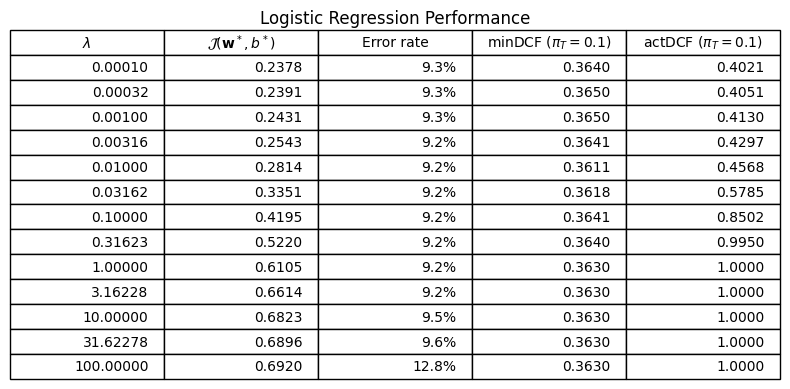

In [108]:
#train and fit binary logistic regression model
AppPriorTrue = 0.1
(_, _, minDCF_l, DCF_l, _) = LR.fitLogReg(DTR, LTR, DVAL, LVAL, lambdas, AppPriorTrue, manual_grad=True)

In [109]:
#they are dictionaries with keys as the lambda values, values as the minDCF/DCF
print(f"minDCF_l: {minDCF_l}")
print(f"DCF_l: {DCF_l}")

minDCF_l: {0.0001: 0.36397529441884274, 0.00031622776601683794: 0.3649673579109063, 0.001: 0.3649673579109063, 0.0031622776601683794: 0.36411930363543266, 0.01: 0.3611431131592422, 0.03162277660168379: 0.36184715821812596, 0.1: 0.36411930363543266, 0.31622776601683794: 0.36397529441884274, 1.0: 0.36298323092677925, 3.1622776601683795: 0.36298323092677925, 10.0: 0.36298323092677925, 31.622776601683793: 0.36298323092677925, 100.0: 0.36298323092677925}
DCF_l: {0.0001: 0.40208973374295953, 0.00031622776601683794: 0.40506592421915, 0.001: 0.4130024321556579, 0.0031622776601683794: 0.42972350230414746, 0.01: 0.4567812339989759, 0.03162277660168379: 0.5785170250896057, 0.1: 0.8501984126984127, 0.31622776601683794: 0.9950396825396826, 1.0: 1.0, 3.1622776601683795: 1.0, 10.0: 1.0, 31.622776601683793: 1.0, 100.0: 1.0}


We can now plot the $\text{DCF}$ and $\text{min DCF}$ as functions of te hyperparameter $\lambda$, using a logarithmic scale for the x-axis of the plot:

In [110]:
def plotDCFasFunctionOfLambda(lambdas, DCF_l, minDCF_l, filename="misscalibration_binaryLR_nonWeighted.png", title="DCF and min DCF as a function of $\lambda$ - weighted binary L.R."):
    #plot the minDCF and DCF as a function of lambda
    #use a log scale for the x-axis
    plt.figure()
    plt.xscale('log', base=10)
    #set y-axis as DCF and minDCF
    series0_yAxis = [DCF_l[lam] for lam in lambdas]
    series1_yAxis = [minDCF_l[lam] for lam in lambdas]

    #set x-axis as lambda
    xAxis = lambdas


    plt.plot(xAxis, series0_yAxis, marker='o', linestyle='-', markersize=1, label=f'DCF($\lambda$)')
    plt.plot(xAxis, series1_yAxis, marker='o', linestyle='-', markersize=1, label=f'min DCF($\lambda$)')

    plt.xlabel('$\lambda$ (log scale)')
    plt.ylabel('DCF/min DCF')
    plt.grid(True)
    plt.legend()
    plt.title(title, fontsize=14, pad= 20)
    plt.savefig(f'./figures/3_LR/{filename}', dpi=300)
    plt.show()


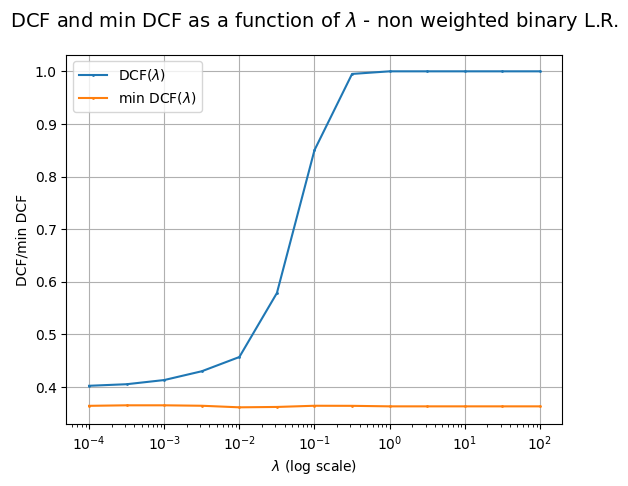

In [111]:
plotDCFasFunctionOfLambda(lambdas, DCF_l, minDCF_l, title="DCF and min DCF as a function of $\lambda$ - non weighted binary L.R.")

In [112]:
logReg_validation = {}

In [113]:
#take the minDCF and DCF for the best lambda
best_lambda_minDCF = min(minDCF_l, key=minDCF_l.get)
minDCF_min = minDCF_l[best_lambda_minDCF]
best_lambda_DCF = min(DCF_l, key=DCF_l.get)
DCF_min = DCF_l[best_lambda_DCF]
#take the DCF using the best lambda of minDCF
DCF_min_bestlambda_min_DCF = DCF_l[best_lambda_minDCF]
logReg_validation['non weighted binary L.R.'] = {
    'minDCF': minDCF_min,
    'DCF': DCF_min_bestlambda_min_DCF,
    'best_lambda_minDCF': best_lambda_minDCF
}


Let's recall that the values of $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ are the normalized empirical Bayes Risk we would obtain with a **perfect score calibration** using the application $(\pi_T, C_{fn}, C_{fp}) = (0.1, 1, 1)$, so the best possible performance for a given set of scores if you could perfectly calibrate them for the target application parameters. <br>
Let's also recall that, based on what we obtain as $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ or $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, we can actually say if our system is *good / useful* or *harmful /useless*:
- if $\text{(min) DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp}) > 1 \Rightarrow$ our system is **harmful**
- if $\text{(min) DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp}) > 1 \Rightarrow$ our system is **good**


So, we can say that all the $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ are below $1$ so the systems, with perfect score calibration, are all good and useful. <br> <br>
However, if we compare the $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ with the $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, we can analyze a **significant loss due to poor score calibration**. <br> **This loss increases for higher values of the regularization term**, $\lambda$! In fact, the actual $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ increases almost exponentially (so, pretty fast) for values of $\lambda$ approximately going from $10^{-3}$ to $2 \cdot 10^{-1}$. Then, for higher values of $\lambda$, let's say for $\lambda > 2 \cdot 10^{-1}$, the we can observe a **plateau** in actual $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, at around $1$. This means that the system is not so good for these values, because it performs almost as well as a  *dummy* system which performs classification just relying on the priors, not using the learned scores! <br>
So, to summarize, **the regularization term widely affects the two metrics, and has a strong impact on the score calibration!** As a matter of facts, if **$\lambda$ is too high, the classes separation gets bad and the score gets very misscalibrated!** The widening gap between the two metrics directy shows the impact of the regularization term on the calibration. <br>
To explain the cause of this behavior, I personally think that the fixed approach of subtracting the training set empirical prior log odds and then thresholding with the application prior log odds, used to adapt the binary L.R. model to our application prior $\pi_T = 0.1$, is **highly ineffective** for high values of $\lambda$.

It's **crucial** to remember that regularization (as in our case, L2 regularization) is often used when the dataset is **small**, to prevent overfitting. In our case, however, since we have a large number of samples, regularization seems ineffective, and actually degrades actual
DCF **since the regularized models tend to lose the probabilistic interpretation of the scores**. Let's explain this last sentence more in detail. It's not that the mathematical form of the probability is lost (you can always pass the score $s(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b$ through a sigmoid to get a value between $0$ and $1$). **Instead, it's about the calibration of these probabilities**. More in detail: when we minimize the average Logistic Loss function **without regularization**:
$$
\text{min}_{\mathbf{w}, b} \text{       } \mathcal{J}(\mathbf{w}, b) = \text{min}_{\mathbf{w}, b} \text{       } \frac{1}{n} \sum_{i = 1}^{n} \log\left( 1 + e^{- z_i (\mathbf{w}^T \mathbf{x}_i + b)}\right)
$$
The model parameters $\left(\mathbf{w},b \right)$ are adjusted such that the output $\sigma(\mathbf{x}, \mathbf{w}, b)$ aims to directly estimate the true conditional probability $P(C = 1 \mid \mathbf{x}_i)$. <br>
​If the model is well-specified (i.e., the true relationship is logistic) and you have enough data, the resulting probabilities are often reasonably **well-calibrated**, which means " If you take all the samples for which the model predicts a probability of, say, $0.8$, then approximately $80$% of those samples should actually belong to class $1$". <br>
If, on the other hand, we introduce the regularization/norm penalty term in the objective function:
$$
\mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \frac{1}{n} \sum_{i = 1}^{n} \log\left( 1 + e^{- z_i (\mathbf{w}^T \mathbf{x}_i + b)}\right) 
$$
Now the model is no longer just trying to make $\sigma(\mathbf{x}, \mathbf{w}, b)$ match the true conditional probability $P(C = 1 \mid \mathbf{x}_i)$, it's doing this while **also trying to comply with the norm penalty contraint**, and the stregth of this contraint increases with $\lambda$. The direct contribution of the regularization term to the model is that:
- it forces the model to choose optimal weights having a **smaller norm**
- Consequently, the resulting scores $s(\mathbf{x}, \mathbf{w}, b) = \mathbf{w}^T \mathbf{x} + b$, since $\mathbf{w}$ will have a smaller norm, will generally be "squashed" closer to $b$ is the bias is not zero, or close to zero.
- By recalling the sigmoid function $\sigma(s(\mathbf{x}, \mathbf{w}, b)) = \sigma(\mathbf{w}^T \mathbf{x} + b)$ trend: <br>
    <div style="text-align: center;">
    <img src="./figures/3_LR/sigmoid.png" alt="image.png" style="background-color: #ADD8E6; width: 400px; height: 200px;">
    </div>

    If, let's say the bias is zero, the score goes close to $0$, the output of the sigmoid function will be close to $0.5$. This means **the model becomes "less confident"** because the probabilities of both classes are not so different (i.e. the distinction between $P(C_i = 1 | \mathbf{x}_i)$ and $P(C_i = 0 | \mathbf{x}_i)$ becomes **smaller**), and more importantly, they are **misscalibrated**: "if you take all samples for which the regularized model predicts $0.7$ for class $1$, the actual proportion of class $1$ samples might be significantly different from $70$%".

So, to better
understand the role of regularization, we analyze the results that we would obtain if we had fewer training
samples. <br> We can keep only 1 out of 50 model training samples (**beware: we apply the filter only on the model training samples, not on the validation samples**..we want to test the model with the full validation samples also because we want to see if it can generalize):

DTR_1OutOf50 shape: (6, 80)
LTR_1OutOf50 shape: (80,)


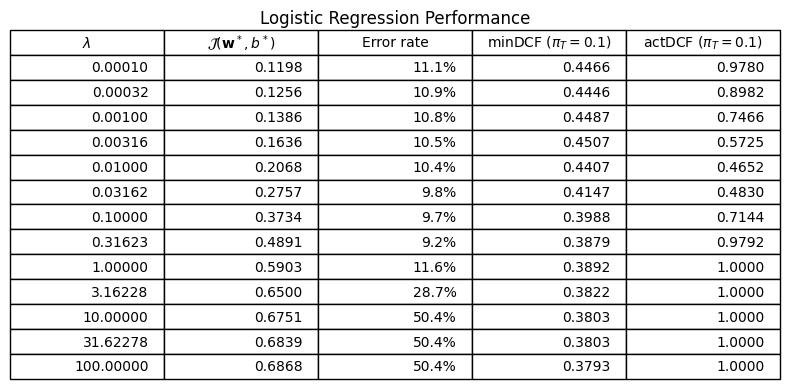

In [114]:
AppPriorTrue = 0.1
DTR_1OutOf50 = DTR[:, ::50]
LTR_1OutOf50 = LTR[::50]
print(f"DTR_1OutOf50 shape: {DTR_1OutOf50.shape}")
print(f"LTR_1OutOf50 shape: {LTR_1OutOf50.shape}")
(_, _, minDCF_l_1OutOf50, DCF_l_1OutOf50, _) = LR.fitLogReg(DTR_1OutOf50, LTR_1OutOf50, DVAL, LVAL, lambdas, AppPriorTrue, manual_grad=True)

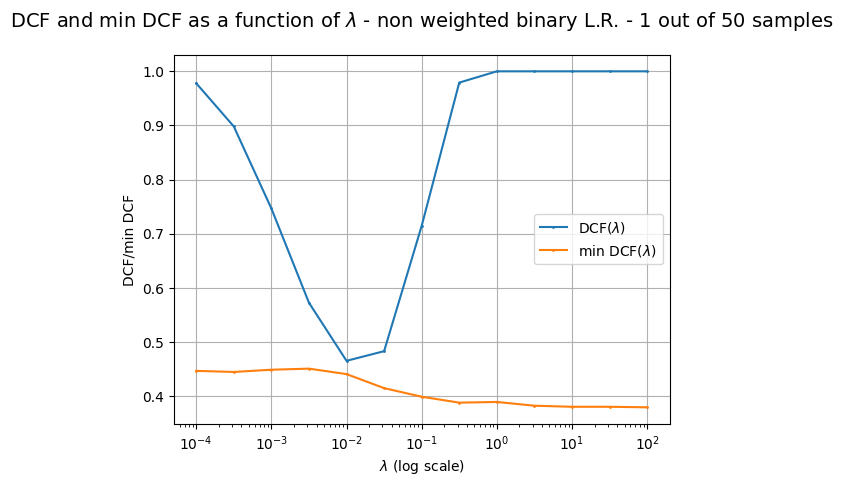

In [115]:
plotDCFasFunctionOfLambda(lambdas, DCF_l_1OutOf50, minDCF_l_1OutOf50, filename="misscalibration_1OutOf50_binaryLR_nonWeighted.png", title="DCF and min DCF as a function of $\lambda$ - non weighted binary L.R. - 1 out of 50 samples")

In this case, we can divide the chart into tree main areas:
- for smaller lambdas, $\lambda \rightarrow 10^{-4}$: we can say that, having now also a smaller dataset, the model can tend to be overconfident and generalization on the validation sample is not good, leading to **overfitting**. In fact, for lower values of $\lambda$, the misscalibration gap is still very wide and gets wider as $\lambda$ gets lower.
- then there is a very important area, centered around $\lambda = 10^{2}$: here we can say this value of $\lambda$ (or a value very close to it, by looking at the chart) is the **perfect one** for our **actual** system: we have a balance between the performance of the model on training data and its generalization on validation data, and because of this **the loss due to misscalibration is minimized**. **It's still not zero**, but it's way smaller than before.
- for higher lambdas, $\lambda > 3 \cdot 10^{-2}$, we can say that the misscalibration gap gets wider again, in this case we can say that the value of $\lambda$ gets **too high**, so class separation gets bad and error rate increases, leading to underfitting and to scores loosing their probabilistic interpretation (as said before).

For either very small or very high value of $\lambda$ the $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ comes very close to 1, this means our system starts becoming harmful and it's not so better than the dummy system. <br>
The only doubt that stems out of this is why the $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ (orange line) is a little higher for the smallest $\lambda$ and goes to a minimum for the highest $\lambda$. I can explain this counter-intuitive phenomenon this way: **there could be different optimal values of $\lambda$ for actual performance of the system and the inherent discriminative power**, dictated by the $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$. <br> More in detail: $\lambda = 10^{2}$ is the "perfect value" for the $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, so for our **actual** system. The $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$, however, reflects the best possible separability if we could perfectly recalibrate the scores for **any** given $\lambda$. This means that, if we could find a way to recalibrate the scores, a **different, higher value of $\lambda$** could lead to absolute best inherent ranking quality.

### Prior-weighted binary L.R.

Now we go back to the full dataset and try the second approach: we directly build a **prior-weighted objective function**. This is achieved by **weighting the loss contribution of each training sample based on our application target prior $\pi_T = 0.1$ and the empirical class frequencies**. <br>
Recall the **non** prior-weighted, regularized average Logistic Loss function is this:
$$
\mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \frac{1}{n} \sum_{i=1}^{n} \log (1 + e^{-z_i(\mathbf{w}^T \mathbf{x}_i + b)})
$$
The crucial part is that in this standard loss function each sample of each class contributes equally to the sum (due to the $\frac{1}{n}$ factor, which averages the loss over all samples). <br>
If we want to have a loss function **more sensitive to the application prior** $\pi_T$, we have to introduce **class specific weights**, that are proportional to the target prior of that class and inversely proportional to the empirical frequency of that class in the training data:
$$
\xi_T = \frac{\pi_T}{n_T}
$$

$$
\xi_F = \frac{\pi_F}{n_F} = \frac{1- \pi_T}{n_F}
$$
where $\pi_T$ is our application prior of $0.1$, and $n_T$ and $n_F$ are the empirical number of samples belonging to class 1 and 0 in the training set. <br>
We can thus rewrite the loss function accounting for the specific contributions of the two classes:
$$\mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \sum_{i \mid c_i = 1} \xi_T \log (1 + e^{-(\mathbf{w}^T \mathbf{x}_i + b)}) + \sum_{i \mid c_i = 0} \xi_F \log (1 + e^{+(\mathbf{w}^T \mathbf{x}_i + b)})$$
Alternatively, using a single weight term $\xi_i$:

$$\mathcal{J}(\mathbf{w}, b) = \frac{\lambda}{2} \|\mathbf{w}\|^2 + \sum_{i=1}^{n} \xi_i \log (1 + e^{-z_i(\mathbf{w}^T \mathbf{x}_i + b)})$$

where

$$
\xi_i = \begin{cases}
\frac{\pi_T}{n_T} & \text{if } z_i = +1 \quad (c_i = 1) \\
\frac{1 - \pi_T}{n_F} & \text{if } z_i = -1 \quad (c_i = 0)
\end{cases}
$$
Beware that if $\pi_T = \pi_{emp}^{LTR}$, i.e. the aplication prior is equivalent to the empirical prior of the training set, we go back to the standard, non prior weighted, loss function. <br>
When computing the gradient for the L-BFGS algorithm, mind that the derivatives account for the weights:
$$
\nabla_{\mathbf{w}} J = \lambda \mathbf{w} + \sum_{i=1}^{n} \xi_i \frac{-z_i}{1 + e^{-z_i(\mathbf{w}^T \mathbf{x}_i + b)}} \mathbf{x}_i = \lambda \mathbf{w} + \sum_{i=1}^{n} \xi_i G_i \mathbf{x}_i
$$

$$
\frac{\partial J}{\partial b} = \sum_{i=1}^{n} \xi_i \frac{-z_i}{1 + e^{-z_i(\mathbf{w}^T \mathbf{x}_i + b)}} = \sum_{i=1}^{n} \xi_i G_i
$$

In [116]:
DTR.shape, LTR.shape, DVAL.shape, LVAL.shape

((6, 4000), (4000,), (6, 2000), (2000,))

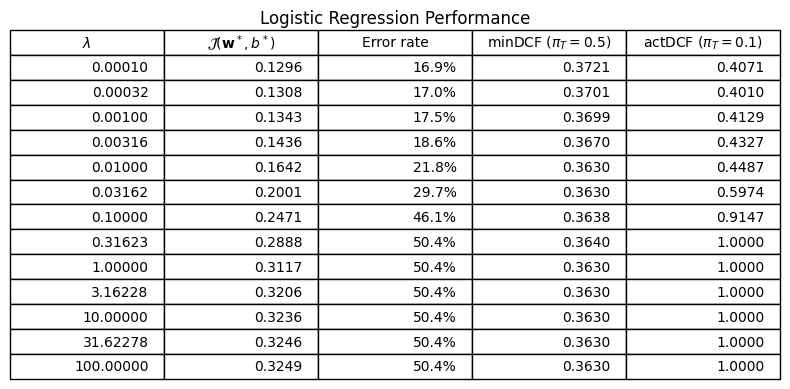

In [117]:
#train and fit prior-weighted binary logistic regression model
AppPriorTrue = 0.1
(_, _, minDCF_l_priorWeighted, DCF_l_priorWeighted, _) = LR.fitLogReg_PriorWeighted(DTR, LTR, DVAL, LVAL, lambdas, AppPriorTrue, manual_grad=True)

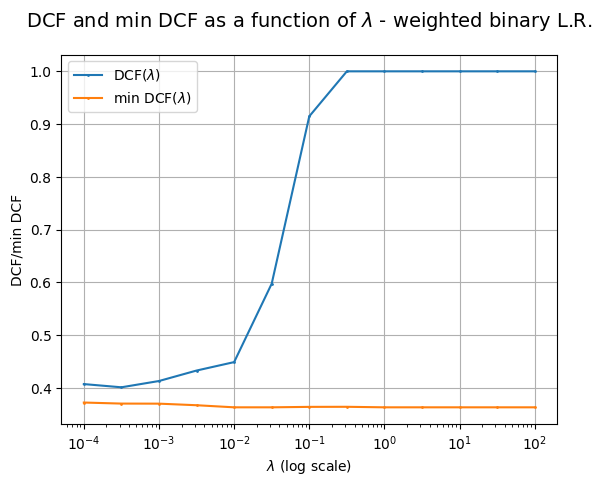

In [118]:
plotDCFasFunctionOfLambda(lambdas, DCF_l_priorWeighted, minDCF_l_priorWeighted, filename="misscalibration_binaryLR_weighted.png",  title="DCF and min DCF as a function of $\lambda$ - weighted binary L.R.")

In [119]:
#take the minDCF and DCF for the best lambda
best_lambda_priorWeighted = min(DCF_l_priorWeighted, key=DCF_l_priorWeighted.get)
DCF_bestlambda_priorWeighted = DCF_l_priorWeighted[best_lambda_priorWeighted]
best_lambda_minDCF_priorWeighted = min(minDCF_l_priorWeighted, key=minDCF_l_priorWeighted.get)
minDCF_bestlambda_priorWeighted = minDCF_l_priorWeighted[best_lambda_minDCF_priorWeighted]
#take the DCF using the best lambda of minDCF
DCF_bestlambda_priorWeighted_minDCF = DCF_l_priorWeighted[best_lambda_minDCF_priorWeighted]
logReg_validation['weighted binary L.R.'] = {
    'minDCF': minDCF_bestlambda_priorWeighted,
    'DCF': DCF_bestlambda_priorWeighted_minDCF,
    'best_lambda_minDCF': best_lambda_minDCF_priorWeighted,
}

In [120]:
expPrior_training = DTR[:, LTR == 1].shape[1] / DTR.shape[1]
print(f"expPrior_training: {expPrior_training}")

expPrior_training: 0.5005


In [121]:
#subtract non-weighted DCF from weighted DCF
diff = {}
for lam in lambdas:
    diff[lam] = DCF_l_priorWeighted[lam] - DCF_l[lam]

diff_min = {}
for lam in lambdas:
    diff_min[lam] = minDCF_l_priorWeighted[lam] - minDCF_l[lam]

print(f"diff: {diff}")
print(f"diff_min: {diff_min}")

number_of_times_weighted_beats_non_weighted = 0
number_of_times_weighted_beats_non_weighted_min = 0
for lam in lambdas:
    if diff[lam] > 0:
        number_of_times_weighted_beats_non_weighted += 1
    if diff_min[lam] > 0:
        number_of_times_weighted_beats_non_weighted_min += 1

print(f"number of times weighted beats non weighted (DCF, minDCF): {number_of_times_weighted_beats_non_weighted, number_of_times_weighted_beats_non_weighted_min}")
print(f"number of times non weighted beats weighted (DCF, minDCF): {len(lambdas) - number_of_times_weighted_beats_non_weighted, len(lambdas) - number_of_times_weighted_beats_non_weighted_min}")

diff: {0.0001: 0.004960317460317443, 0.00031622776601683794: -0.004112263184843812, 0.001: -0.00014400921658980215, 0.0031622776601683794: 0.0029761904761904656, 0.01: -0.00808051715309771, 0.03162277660168379: 0.018849206349206393, 0.1: 0.06448412698412709, 0.31622776601683794: 0.004960317460317443, 1.0: 0.0, 3.1622776601683795: 0.0, 10.0: 0.0, 31.622776601683793: 0.0, 100.0: 0.0}
diff_min: {0.0001: 0.008080517153097821, 0.00031622776601683794: 0.0051043266769073, 0.001: 0.004960317460317443, 0.0031622776601683794: 0.002832181259600608, 0.01: 0.001840117767537064, 0.03162277660168379: 0.0011360727086532907, 0.1: -0.0002880184331797153, 0.31622776601683794: 0.0, 1.0: 0.0, 3.1622776601683795: 0.0, 10.0: 0.0, 31.622776601683793: 0.0, 100.0: 0.0}
number of times weighted beats non weighted (DCF, minDCF): (5, 6)
number of times non weighted beats weighted (DCF, minDCF): (8, 7)


TODO: How can we explain this?

### Quadratic binary L.R.

Then we can try to see if a model which can go beyond linear decision surfaces can do a better job at classifying our dataset. So, we introduce the **non linear Logistic Regression**. <br>
We can build a non prior-weighted **quadratic** L.R. model, by imposing a decision surface which is quadratic wrt the features $\mathbf{x}$:
$$
s(\mathbf{x}, \mathbf{A}, \mathbf{b}, c) = \mathbf{x}\mathbf{A}\mathbf{x}^T + \mathbf{b}^T \mathbf{x} + c
$$
However, we can note that, despite being quadratic wrt the features, it's still linear wrt matrix $\mathbf{A}$, vector $\mathbf{b}$ and bias $c$, so we can introduce a suitabe transformation to work linearly in an expanded features space:
$$\phi(\mathbf{x}) = \begin{bmatrix} \text{vec}(\mathbf{x}\mathbf{x}^T) \\ \mathbf{x} \end{bmatrix}$$

$$\mathbf{w} = \begin{bmatrix} \text{vec}(\mathbf{A}) \\ b \end{bmatrix}$$
So, in the expanded feature space of $\phi(\mathbf{x})$, we can rewrite the score as a linear function and just work with it in this space. This translates into a quadratic function in the original features space of $\mathbf{x}$:
$$
s(\phi(\mathbf{x}), \mathbf{w}, c) = \mathbf{w}^T \phi(\mathbf{x}) + c
$$


We can write a function for the transformation $\phi(\mathbf{x})$, We have to have qudratic feature vectors for each sample:

In [122]:
def phi(DTR):
    n_features, n_samples = DTR.shape
    DTR_quadratic = np.zeros((n_features**2, n_samples)) #it's like now each sample has n_features^2 features

    #now, iterates through every feature vector of the original space and do x @ x.T
    for i in range(n_samples):
       #for the i-th sample, take all of its features
       x = DTR[:, i:i+1] #x is a column vector of shape (n_features, 1) and represents the i-th sample
       #compute x @ x.T
       quadraticX = x @ x.T #quadratic sample

       #do vec(x @ x.T) to get the vectorized version of the quadratic sample
       vectorizedQuadraticX = quadraticX.flatten() 

       DTR_quadratic[:, i] = vectorizedQuadraticX


    #at the end we need to stack the original feature vectors (so the original samples)
    return np.vstack((DTR_quadratic, DTR))


    

Then we can work in the linear space excacly like before, the score we compute here translates in a quadratic score in the real, original, features space.

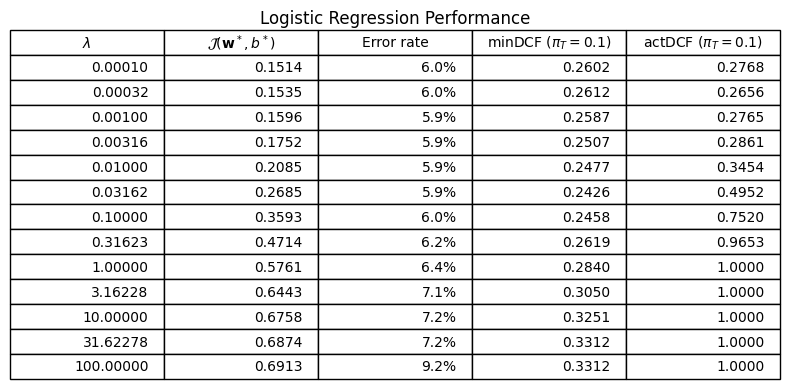

In [123]:
AppPriorTrue = 0.1
(_, _, minDCF_l_quadraticLR, DCF_l_quadraticLR, _) = LR.fitLogReg(phi(DTR), LTR, phi(DVAL), LVAL, lambdas, AppPriorTrue, manual_grad=True)

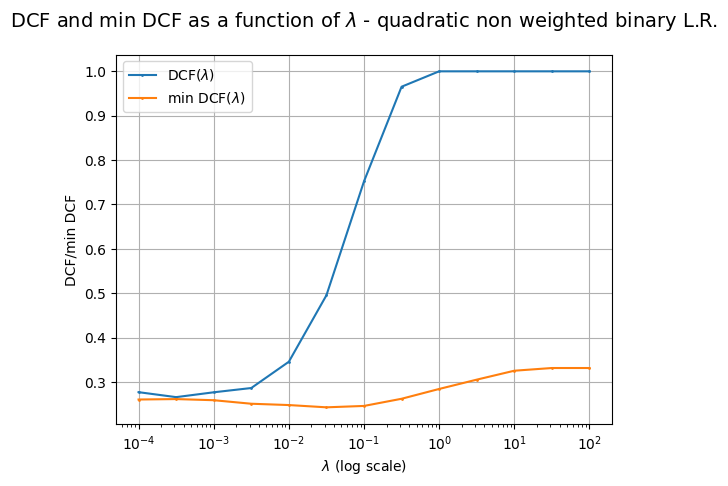

In [124]:
plotDCFasFunctionOfLambda(lambdas, DCF_l_quadraticLR, minDCF_l_quadraticLR, filename="misscalibration_quadraticBinaryLR_nonWeighted.png",  title="DCF and min DCF as a function of $\lambda$ - quadratic non weighted binary L.R.")

In [125]:
#take the minDCF and DCF for the best lambda
best_lambda_quadraticDCF = min(DCF_l_quadraticLR, key=DCF_l_quadraticLR.get)
DCF_quadratic_min = DCF_l_quadraticLR[best_lambda_quadraticDCF]
best_lambda_quadratic_minDCF = min(minDCF_l_quadraticLR, key=minDCF_l_quadraticLR.get)
minDCF_quadratic_min = minDCF_l_quadraticLR[best_lambda_quadratic_minDCF]
#take the DCF using the best lambda of minDCF
DCF_quadratic_min_bestlambda_minDCF = DCF_l_quadraticLR[best_lambda_quadratic_minDCF]
logReg_validation['quadratic binary L.R.'] = {
    'minDCF': minDCF_quadratic_min,
    'DCF': DCF_quadratic_min_bestlambda_minDCF,
    'best_lambda_minDCF': best_lambda_quadratic_minDCF
}

We can say that for $10^{-4} \leq \lambda \leq 3 \cdot 10^{-3}$ the misscalibration gap is **small**, so there's generally a good score calibration. Also, it's important to note both $\text{DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ and $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$ are below $0.3$ in this range, whereas with all the other models they were $\geq 0.4$, so overall the use of a quadratic decision rule **clearly improves** the loss due to misscalibration and the error rates (which are the lowest observed) for this range of $\lambda$. If however $\lambda$ gets higher, both misscalibration and error rate get higher, like before. <br>
**For $\lambda \leq 10^{-1}$ we can say that it's also the best model in terms of $\text{min DCF}(\lambda_T, \pi_T, C_{fn}, C_{fp})$**.

So, the best models in terms of minimum DCF are not necessarily those that
provide the best actual DCFs, i.e., they may present significant mis-calibration. We will deal with score
calibration soon.

So, we can keep in mind how good are the $\text{min DCF}(\pi_T, C_{fn}, C_{fp})$ of all our models, having our application prior $\pi_T = 0.1$. The values for the Gaussian Generative Models are taken from the previous notebook.

In [126]:
min(DCF_l)

0.0001

In [127]:
minDCF_l_priorWeighted

{0.0001: 0.37205581157194056,
 0.00031622776601683794: 0.3700716845878136,
 0.001: 0.36992767537122373,
 0.0031622776601683794: 0.36695148489503326,
 0.01: 0.36298323092677925,
 0.03162277660168379: 0.36298323092677925,
 0.1: 0.36383128520225294,
 0.31622776601683794: 0.36397529441884274,
 1.0: 0.36298323092677925,
 3.1622776601683795: 0.36298323092677925,
 10.0: 0.36298323092677925,
 31.622776601683793: 0.36298323092677925,
 100.0: 0.36298323092677925}

In [128]:
print(logReg_validation)

{'non weighted binary L.R.': {'minDCF': 0.3611431131592422, 'DCF': 0.4567812339989759, 'best_lambda_minDCF': 0.01}, 'weighted binary L.R.': {'minDCF': 0.36298323092677925, 'DCF': 0.4487007168458782, 'best_lambda_minDCF': 0.01}, 'quadratic binary L.R.': {'minDCF': 0.2426395289298515, 'DCF': 0.4951836917562724, 'best_lambda_minDCF': 0.03162277660168379}}


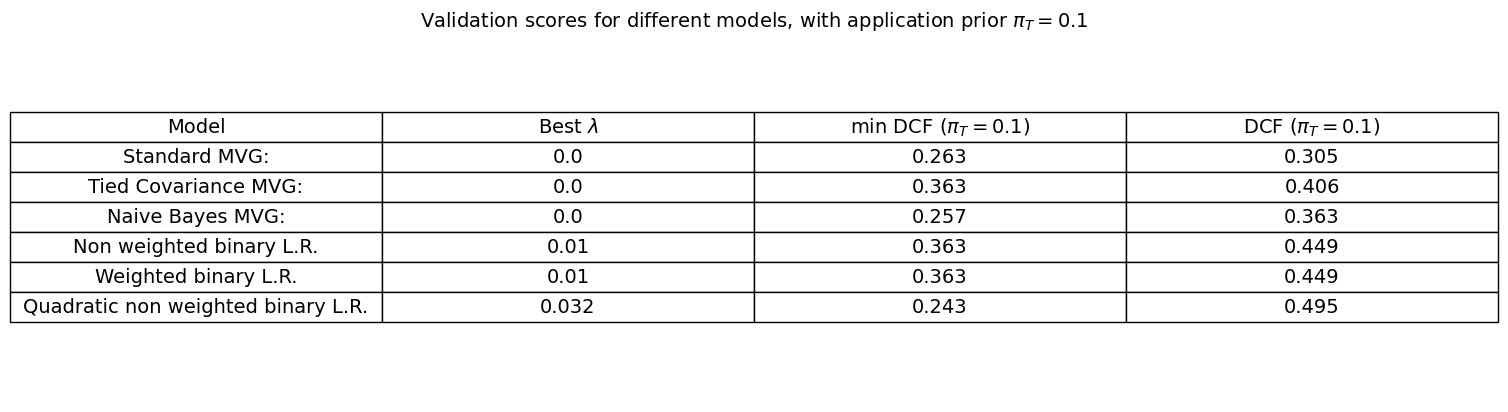

In [135]:
#write min dcf in file
#for each model, take the lambda corresponding to the minDCF and write it in a file



#load ggm minDCF
with open('./models/minDCF_appPrior/ggm.txt', 'r') as f:
    lines = f.readlines()
    #in line 0
    minDCF_MVG = float(lines[0].split(',')[2].split(':')[1].strip())
    DCF_MVG = float(lines[0].split(',')[1].split(':')[1].strip())
    minDCF_MVG_tied = float(lines[0].split(',')[4].split(':')[1].strip())
    DCF_MVG_tied = float(lines[0].split(',')[3].split(':')[1].strip())
    minDCF_MVG_naive = float(lines[0].split(',')[6].split(':')[1].strip())
    DCF_MVG_naive = float(lines[0].split(',')[4].split(':')[1].strip())

models_minDCF_01 = {
    "Standard MVG:": minDCF_MVG,
    "Tied Covariance MVG:": minDCF_MVG_tied,
    "Naive Bayes MVG:": minDCF_MVG_naive,
    'Non weighted binary L.R.': logReg_validation['weighted binary L.R.']['minDCF'],
    'Weighted binary L.R.': logReg_validation['weighted binary L.R.']['minDCF'],
    'Quadratic non weighted binary L.R.': logReg_validation['quadratic binary L.R.']['minDCF'],
}

models_DCF_01 = {
    "Standard MVG:": DCF_MVG,
    "Tied Covariance MVG:": DCF_MVG_tied,
    "Naive Bayes MVG:": DCF_MVG_naive,
    'Non weighted binary L.R.': logReg_validation['weighted binary L.R.']['DCF'],
    'Weighted binary L.R.': logReg_validation['weighted binary L.R.']['DCF'],
    'Quadratic non weighted binary L.R.': logReg_validation['quadratic binary L.R.']['DCF'],
}

lambdas_table = {
    "Standard MVG:": 0.0,
    "Tied Covariance MVG:": 0.0,
    "Naive Bayes MVG:": 0.0,
    'Non weighted binary L.R.': logReg_validation['non weighted binary L.R.']['best_lambda_minDCF'],
    'Weighted binary L.R.': logReg_validation['weighted binary L.R.']['best_lambda_minDCF'],
    'Quadratic non weighted binary L.R.': logReg_validation['quadratic binary L.R.']['best_lambda_minDCF'],
}

#show this in a table
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
table_data = []
for model in models_minDCF_01.keys():
    minDCF = models_minDCF_01[model]
    DCF = models_DCF_01[model]
    table_data.append([model, round(lambdas_table[model], 3), round(minDCF, 3), round(DCF, 3)])

table = ax.table(cellText=table_data, colLabels=['Model', 'Best $\lambda$', 'min DCF ($\pi_T = 0.1$)', 'DCF ($\pi_T = 0.1$)'], cellLoc='center', loc='center')

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(3, 1.8)
plt.title("Validation scores for different models, with application prior $\pi_T = 0.1$", fontsize=14, pad=1)
plt.savefig('./figures/validationScores_allModels_appPrior_0.1.png', dpi=300, bbox_inches='tight')
plt.show()

